# Case 6 — Analisis Drill Down & Risk Profile Mapping
### Studi Kasus: Kolaborasi PT AXA Insurance Indonesia & Universitas Airlangga 2026
---
Notebook ini dibuat untuk menyelesaikan **Case 6 (Drill Down Analysis & Risk Profile Mapping)** pada data asuransi umum AXA Insurance Indonesia. Analisis ini menggali lebih dalam dari level *Class of Business* (COB) ke tingkat segmen yang lebih spesifik untuk menemukan akar masalah (*root cause*) kerugian portofolio, serta memetakan profil risiko untuk mendukung rekomendasi strategis manajemen.

### Struktur Analisis:
1. **Persiapan Data & Preprocessing**: Penanganan kualitas data, konversi tanggal, dan mitigasi duplikasi akibat pembayaran premi bertahap (*installment*).
2. **Analisis Portofolio & Dampak Reasuransi (Insight Tambahan)**: Evaluasi efisiensi transfer risiko dari posisi *Gross* vs *Net*.
3. **Step 8 — Analisis Drill Down**: Menelusuri profitabilitas, keparahan klaim (*claim severity*), dan eksposur di 5 level dimensi kombinasi.
4. **Step 9 — Risk Profile Mapping (Output Utama)**: Pengelompokan segmen ke dalam 4 kuadran risiko (*Critical Risk*, *Strategic*, *Inefficient*, *Stable*) menggunakan *Bubble Chart*.
5. **Kesimpulan Eksekutif & Rekomendasi Strategis**: Langkah konkret underwriting, pricing, dan reasuransi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
print("Library berhasil diimpor dan konfigurasi visualisasi diterapkan!")


Library berhasil diimpor dan konfigurasi visualisasi diterapkan!


## 1. Load Data dan Eksplorasi Awal
Kami akan memuat sheet `Raw Premium` (Data Produksi Premi) dan `Raw Claim` (Data Klaim) dari file Excel studi kasus.


In [2]:
file_name = 'Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26).xlsx'
if not os.path.exists(file_name):
    raise FileNotFoundError(f"File {file_name} tidak ditemukan di direktori kerja saat ini.")

print("Membaca data dari Excel (proses ini memakan waktu beberapa detik karena ukuran file besar)... ")
df_prem = pd.read_excel(file_name, sheet_name='Raw Premium')
df_claim = pd.read_excel(file_name, sheet_name='Raw Claim')

print("\n--- Ringkasan Dataset ---")
print(f"Ukuran sheet Raw Premium: {df_prem.shape[0]:,} baris, {df_prem.shape[1]} kolom")
print(f"Ukuran sheet Raw Claim: {df_claim.shape[0]:,} baris, {df_claim.shape[1]} kolom")

print("\nKolom pada Premium:", df_prem.columns.tolist())
print("Kolom pada Claim:", df_claim.columns.tolist())


Membaca data dari Excel (proses ini memakan waktu beberapa detik karena ukuran file besar)... 

--- Ringkasan Dataset ---
Ukuran sheet Raw Premium: 390,124 baris, 12 kolom
Ukuran sheet Raw Claim: 20,087 baris, 10 kolom

Kolom pada Premium: ['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME', 'POLICY_NO', 'DT_INC', 'DT_END', 'GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED']
Kolom pada Claim: ['COB', 'BRANCH_', 'CHANNEL_', 'POLICY_NO', 'CLM_REF', 'DT_CLM', 'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']


## 2. Preprocessing & Pembersihan Data
**Mitigasi Distorsi Duplikasi Premi & Join Cardality**:
1. **Installment Issue**: Satu nomor polis (`POLICY_NO`) dapat muncul berkali-kali di sheet `Raw Premium` karena pembayaran bertahap (*installments*) atau endorsement. Jika kita langsung melakukan SQL-like `merge` antara tabel Claim and Premium berdasarkan `POLICY_NO`, setiap baris klaim akan terduplikasi sebanyak baris premi dari polis tersebut. Hal ini akan **menggelembungkan nilai klaim secara keliru** (*cartesian product*).
2. **Solusi Agregasi**: Untuk menghindarinya, agregasi klaim dan premi harus dilakukan secara **independen** pada dimensi analisis yang diinginkan (misal segmentasi `COB` dan `BRANCH_`), baru kemudian hasil agregasinya digabungkan.
3. **Pemetaan Produk**: Karena sheet `Raw Claim` tidak memiliki kolom `PRODUCT_NAME`, kita perlu memetakan `PRODUCT_NAME` dari sheet `Raw Premium` ke sheet `Raw Claim` berdasarkan `POLICY_NO`. Kita membuat *dictionary mapping* unik dari Premium karena satu polis hampir selalu hanya diasosiasikan dengan satu nama produk.
4. **Konversi Tanggal**: Mengubah kolom tanggal menjadi tipe datetime untuk analisis berbasis waktu jika diperlukan.


In [3]:
# 1. Konversi format tanggal
df_prem['DT_INC'] = pd.to_datetime(df_prem['DT_INC'], errors='coerce')
df_prem['DT_END'] = pd.to_datetime(df_prem['DT_END'], errors='coerce')
df_claim['DT_CLM'] = pd.to_datetime(df_claim['DT_CLM'], errors='coerce')

# 2. Penanganan nilai kosong pada metrik keuangan (diisi dengan 0)
df_prem['RWP_IDR'] = df_prem['RWP_IDR'].fillna(0)
df_prem['RWC_IDR'] = df_prem['RWC_IDR'].fillna(0)
df_claim['RI_ST_IDR'] = df_claim['RI_ST_IDR'].fillna(0)
df_claim['RI_OS_IDR'] = df_claim['RI_OS_IDR'].fillna(0)

# 3. Membuat pemetaan POLICY_NO -> PRODUCT_NAME dari sheet Premium
# Menggunakan .first() karena tiap nomor polis umumnya hanya memiliki 1 nama produk
policy_product_map = df_prem.groupby('POLICY_NO')['PRODUCT_NAME'].first().to_dict()

# Terapkan pemetaan ke tabel Claim
df_claim['PRODUCT_NAME'] = df_claim['POLICY_NO'].map(policy_product_map)

# 4. Validasi hasil pemetaan
missing_products = df_claim['PRODUCT_NAME'].isna().sum()
print(f"Klaim yang tidak memiliki padanan polis di tabel Premium: {missing_products}")
if missing_products > 0:
    # Jika ada klaim tanpa padanan produk, isi dengan 'UNKNOWN PRODUCT'
    df_claim['PRODUCT_NAME'] = df_claim['PRODUCT_NAME'].fillna('UNKNOWN PRODUCT')

print("Preprocessing data selesai! Kolom PRODUCT_NAME berhasil ditambahkan ke dataset klaim.")


Klaim yang tidak memiliki padanan polis di tabel Premium: 0
Preprocessing data selesai! Kolom PRODUCT_NAME berhasil ditambahkan ke dataset klaim.


## 3. Analisis Kinerja Portofolio Keseluruhan & Dampak Reasuransi
Sebelum melakukan drill-down, penting untuk melihat posisi keuangan portofolio secara makro, baik dari sisi **Gross** (sebelum reasuransi) maupun **Net** (setelah dampak reasuransi).

**Metrik Utama Aktuaris**:
- **Gross Written Premium (GWP)**: Total premi yang ditulis.
- **Net Written Premium (NWP)**: GWP dikurangi premi yang didelegasikan ke reasuradur (RWP).
- **Gross Incurred Claims**: Total klaim kotor = Klaim Bayar (Gross Paid / `GRS_ST_IDR`) + Cadangan Klaim (Gross Outstanding / `GRS_OS_IDR`).
- **Net Incurred Claims**: Gross Incurred Claims dikurangi pemulihan reasuransi (Reinsurance Recovery Paid + Outstanding).
- **Loss Ratio**: Rasio klaim terhadap premi (Klaim Incurred / Premi Written).


In [4]:
# Hitung total metrik premium
total_gwp = df_prem['GWP_IDR'].sum()
total_rwp = df_prem['RWP_IDR'].sum()
total_nwp = total_gwp - total_rwp
re_premium_ceded_pct = (total_rwp / total_gwp) * 100

# Hitung total metrik klaim
total_gross_paid = df_claim['GRS_ST_IDR'].sum()
total_gross_os = df_claim['GRS_OS_IDR'].sum()
total_gross_incurred = total_gross_paid + total_gross_os

total_ri_paid = df_claim['RI_ST_IDR'].sum()
total_ri_os = df_claim['RI_OS_IDR'].sum()
total_ri_recovery = total_ri_paid + total_ri_os

total_net_incurred = total_gross_incurred - total_ri_recovery
re_claim_recovery_pct = (total_ri_recovery / total_gross_incurred) * 100

# Hitung Loss Ratio keseluruhan
gross_loss_ratio = (total_gross_incurred / total_gwp) * 100
net_loss_ratio = (total_net_incurred / total_nwp) * 100

print("=== RINGKASAN PORTOFOLIO KEUANGAN ===")
print(f"Gross Written Premium (GWP)  : IDR {total_gwp:,.2f}")
print(f"Reinsurance Ceded (RWP)      : IDR {total_rwp:,.2f} ({re_premium_ceded_pct:.2f}% dari GWP)")
print(f"Net Written Premium (NWP)    : IDR {total_nwp:,.2f}")
print("-" * 50)
print(f"Gross Paid Claims (GRS_ST)   : IDR {total_gross_paid:,.2f}")
print(f"Gross Outstanding Claims (OS): IDR {total_gross_os:,.2f} ({total_gross_os/total_gross_incurred*100:.2f}% dari total klaim)")
print(f"Gross Incurred Claims (GIC)  : IDR {total_gross_incurred:,.2f}")
print(f"Reinsurance Recoveries (RI)  : IDR {total_ri_recovery:,.2f} ({re_claim_recovery_pct:.2f}% dari Gross Klaim)")
print(f"Net Incurred Claims (NIC)    : IDR {total_net_incurred:,.2f}")
print("-" * 50)
print(f"OVERALL GROSS LOSS RATIO     : {gross_loss_ratio:.2f}%")
print(f"OVERALL NET LOSS RATIO       : {net_loss_ratio:.2f}%")


=== RINGKASAN PORTOFOLIO KEUANGAN ===
Gross Written Premium (GWP)  : IDR 2,510,719,474,050.44
Reinsurance Ceded (RWP)      : IDR 546,598,216,481.78 (21.77% dari GWP)
Net Written Premium (NWP)    : IDR 1,964,121,257,568.66
--------------------------------------------------
Gross Paid Claims (GRS_ST)   : IDR 1,183,397,481,372.40
Gross Outstanding Claims (OS): IDR 55,484,083,656.07 (4.48% dari total klaim)
Gross Incurred Claims (GIC)  : IDR 1,238,881,565,028.47
Reinsurance Recoveries (RI)  : IDR 89,128,475,259.40 (7.19% dari Gross Klaim)
Net Incurred Claims (NIC)    : IDR 1,149,753,089,769.06
--------------------------------------------------
OVERALL GROSS LOSS RATIO     : 49.34%
OVERALL NET LOSS RATIO       : 58.54%


> [!NOTE]
> **Insight Utama Dampak Reasuransi (Gross vs Net):**
> - Perusahaan menyerahkan **21.72%** preminya ke reasuradur, namun hanya mendapatkan pemulihan klaim sebesar **7.20%** dari total klaim yang terjadi.
> - Akibatnya, **Net Loss Ratio (58.54%) naik secara signifikan** dibandingkan dengan Gross Loss Ratio (49.34%).
> - Hal ini mengindikasikan bahwa struktur reasuransi yang ada saat ini kurang efisien bagi perusahaan (*under-recovering claims*), atau portofolio yang diserahkan memiliki rasio klaim yang sangat rendah sehingga menguntungkan reasuradur secara sepihak. Rekomendasi taktis: Tinjau ulang batas retensi sendiri (*self-retention limit*) and struktur treaty reasuransi.


## 4. Step 8 — Analisis Drill Down
Sesuai instruksi pada Case 6, kita tidak boleh berhenti pada analisis tingkat COB saja, melainkan harus melakukan investigasi mendalam untuk menemukan akar masalah (*root cause*). Kita akan menghitung profitabilitas (Loss Ratio) dan eksposur (Sum Insured) pada 5 level kombinasi dimensi:
1. **COB × Branch**
2. **COB × Channel**
3. **COB × Product**
4. **COB × Branch × Channel**
5. **COB × Branch × Channel × Product**

Tujuan: Mengidentifikasi segmen spesifik dengan *Loss Ratio* tinggi, eksposur tinggi, dan jumlah klaim besar.


In [5]:
# Fungsi pembantu untuk agregasi tanpa duplikasi join
def analyze_drilldown(dimensions):
    # Agregasi Premium
    p_agg = df_prem.groupby(dimensions).agg(
        GWP=('GWP_IDR', 'sum'),
        Exposure=('SUM_INSURED', 'sum')
    ).reset_index()
    
    # Tambahkan kolom klaim incurred ke sheet Claim untuk kemudahan
    df_claim['gross_incurred'] = df_claim['GRS_ST_IDR'] + df_claim['GRS_OS_IDR']
    df_claim['net_incurred'] = (df_claim['GRS_ST_IDR'] - df_claim['RI_ST_IDR']) + (df_claim['GRS_OS_IDR'] - df_claim['RI_OS_IDR'])
    
    # Agregasi Claim
    c_agg = df_claim.groupby(dimensions).agg(
        Gross_Claims=('gross_incurred', 'sum'),
        Net_Claims=('net_incurred', 'sum'),
        Claim_Count=('CLM_REF', 'count')
    ).reset_index()
    
    # Gabungkan data Premium dan Claim
    merged = pd.merge(p_agg, c_agg, on=dimensions, how='outer').fillna(0)
    merged['Loss_Ratio_Gross'] = (merged['Gross_Claims'] / merged['GWP']) * 100
    merged['Claim_Severity_Gross'] = np.where(merged['Claim_Count'] > 0, merged['Gross_Claims'] / merged['Claim_Count'], 0)
    
    return merged

# Menjalankan 5 kombinasi drill-down
df_cob_branch = analyze_drilldown(['COB', 'BRANCH_'])
df_cob_channel = analyze_drilldown(['COB', 'CHANNEL_'])
df_cob_product = analyze_drilldown(['COB', 'PRODUCT_NAME'])
df_cob_branch_channel = analyze_drilldown(['COB', 'BRANCH_', 'CHANNEL_'])
df_cob_all = analyze_drilldown(['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME'])

print("Agregasi 5 level dimensi selesai!")


Agregasi 5 level dimensi selesai!


In [6]:
print("=== TOP 5 WORST SEGMENTS: COB x Branch (Sorted by Gross Claims) ===")
print(df_cob_branch.sort_values('Gross_Claims', ascending=False).head(5).to_string(index=False))
print("\n=== TOP 5 WORST SEGMENTS: COB x Branch (Sorted by Loss Ratio, min GWP > 5Miliar) ===")
print(df_cob_branch[df_cob_branch['GWP'] > 5e9].sort_values('Loss_Ratio_Gross', ascending=False).head(5).to_string(index=False))


=== TOP 5 WORST SEGMENTS: COB x Branch (Sorted by Gross Claims) ===
  COB  BRANCH_                GWP               Exposure       Gross_Claims         Net_Claims  Claim_Count  Loss_Ratio_Gross  Claim_Severity_Gross
COB 6 BRANCH K 407,239,040,832.32  54,549,840,456,088.29 373,525,993,178.03 373,525,993,178.03     1,434.00             91.72        260,478,377.39
COB 4 BRANCH K 218,874,069,875.30 435,194,935,786,868.56 243,367,347,744.47 235,402,710,397.39     1,156.00            111.19        210,525,387.32
COB 7 BRANCH K  38,044,558,398.67   2,246,441,013,114.63 191,614,345,151.15 191,614,345,151.15     1,687.00            503.66        113,582,895.76
COB 9 BRANCH K 287,082,563,876.88 405,074,787,767,067.62  76,036,880,413.15  44,473,717,798.43     2,444.00             26.49         31,111,653.20
COB 7 BRANCH J 104,275,055,108.61   6,233,383,862,093.20  39,573,852,496.64  39,544,162,756.64     4,273.00             37.95          9,261,374.33

=== TOP 5 WORST SEGMENTS: COB x Branch (Sor

In [7]:
print("=== TOP 5 WORST SEGMENTS: COB x Channel (Sorted by Gross Claims) ===")
print(df_cob_channel.sort_values('Gross_Claims', ascending=False).head(5).to_string(index=False))
print("\n=== TOP 5 WORST SEGMENTS: COB x Channel (Sorted by Loss Ratio, min GWP > 5Miliar) ===")
print(df_cob_channel[df_cob_channel['GWP'] > 5e9].sort_values('Loss_Ratio_Gross', ascending=False).head(5).to_string(index=False))


=== TOP 5 WORST SEGMENTS: COB x Channel (Sorted by Gross Claims) ===
  COB  CHANNEL_                GWP               Exposure       Gross_Claims         Net_Claims  Claim_Count  Loss_Ratio_Gross  Claim_Severity_Gross
COB 6 CHANNEL B 395,298,471,610.01  50,995,201,899,563.02 373,362,644,819.65 373,362,644,819.65     1,415.00             94.45        263,860,526.37
COB 4 CHANNEL C 239,483,568,416.55 464,464,808,771,412.94 251,581,774,924.38 240,596,519,782.07     1,184.00            105.05        212,484,607.20
COB 7 CHANNEL B  17,621,754,238.45     799,575,693,098.75 178,253,071,430.67 178,253,071,430.67     1,000.00          1,011.55        178,253,071.43
COB 9 CHANNEL C 277,446,993,583.50 395,412,982,454,301.62  73,255,539,074.44  43,192,960,762.50     2,436.00             26.40         30,072,060.38
COB 7 CHANNEL E  58,334,725,803.15   4,340,056,465,855.53  45,397,480,909.54  45,397,480,909.54     4,090.00             77.82         11,099,628.58

=== TOP 5 WORST SEGMENTS: COB x Chan

In [8]:
print("=== TOP 5 WORST SEGMENTS: COB x Product (Sorted by Gross Claims) ===")
print(df_cob_product.sort_values('Gross_Claims', ascending=False).head(5).to_string(index=False))
print("\n=== TOP 5 WORST SEGMENTS: COB x Product (Sorted by Loss Ratio, min GWP > 1Miliar) ===")
print(df_cob_product[df_cob_product['GWP'] > 1e9].sort_values('Loss_Ratio_Gross', ascending=False).head(5).to_string(index=False))


=== TOP 5 WORST SEGMENTS: COB x Product (Sorted by Gross Claims) ===
  COB PRODUCT_NAME                GWP               Exposure       Gross_Claims         Net_Claims  Claim_Count  Loss_Ratio_Gross  Claim_Severity_Gross
COB 6  PRODUCT1217   1,738,130,096.12     173,668,543,995.00 366,456,399,711.30 366,456,399,711.30       437.00         21,083.37        838,572,997.05
COB 4  PRODUCT0311 293,808,830,710.02 530,365,682,403,194.50 288,026,668,096.73 278,806,413,828.43     1,234.00             98.03        233,408,969.28
COB 7  PRODUCT0221 223,105,437,125.89  13,787,573,035,033.22 268,859,246,040.59 268,859,246,040.59    10,945.00            120.51         24,564,572.50
COB 9  PRODUCT0109 143,013,994,800.48 208,792,821,424,255.47  58,961,024,180.80  36,483,485,549.60     1,878.00             41.23         31,395,646.53
COB 5  PRODUCT0401 149,492,730,892.65  24,959,130,411,083.50  58,025,722,142.83  37,047,819,857.04        80.00             38.82        725,321,526.79

=== TOP 5 WORST SE

In [9]:
print("=== TOP 5 WORST SEGMENTS: COB x Branch x Channel (Sorted by Gross Claims) ===")
print(df_cob_branch_channel.sort_values('Gross_Claims', ascending=False).head(5).to_string(index=False))


=== TOP 5 WORST SEGMENTS: COB x Branch x Channel (Sorted by Gross Claims) ===
  COB  BRANCH_  CHANNEL_                GWP               Exposure       Gross_Claims         Net_Claims  Claim_Count  Loss_Ratio_Gross  Claim_Severity_Gross
COB 6 BRANCH K CHANNEL B 395,298,471,610.01  50,995,201,899,563.02 373,362,644,819.65 373,362,644,819.65     1,415.00             94.45        263,860,526.37
COB 4 BRANCH K CHANNEL C 217,614,117,192.51 433,193,680,717,850.19 242,774,910,240.66 234,810,272,893.58     1,154.00            111.56        210,376,871.96
COB 7 BRANCH K CHANNEL B  17,621,754,238.45     799,575,693,098.75 178,253,071,430.67 178,253,071,430.67     1,000.00          1,011.55        178,253,071.43
COB 9 BRANCH K CHANNEL C 277,444,046,099.89 395,409,544,954,301.62  73,255,539,074.44  43,192,960,762.50     2,436.00             26.40         30,072,060.38
COB 5 BRANCH K CHANNEL C  80,279,937,697.41  12,499,385,000,065.50  30,757,534,023.28  12,056,720,599.65        25.00             38

In [10]:
print("=== TOP 10 WORST SEGMENTS: COB x Branch x Channel x Product (Sorted by Loss Ratio, min GWP > 100Juta) ===")
cols_show = ['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME', 'GWP', 'Exposure', 'Gross_Claims', 'Claim_Count', 'Loss_Ratio_Gross']
print(df_cob_all[df_cob_all['GWP'] > 1e8].sort_values('Loss_Ratio_Gross', ascending=False).head(10)[cols_show].to_string(index=False))


=== TOP 10 WORST SEGMENTS: COB x Branch x Channel x Product (Sorted by Loss Ratio, min GWP > 100Juta) ===
  COB  BRANCH_  CHANNEL_ PRODUCT_NAME               GWP             Exposure       Gross_Claims  Claim_Count  Loss_Ratio_Gross
COB 6 BRANCH K CHANNEL B  PRODUCT1217  1,738,130,096.12   173,668,543,995.00 366,456,399,711.30       437.00         21,083.37
COB 6 BRANCH K CHANNEL B  PRODUCT1221    262,428,679.70     8,015,751,625.00   6,860,851,407.85       971.00          2,614.37
COB 7 BRANCH K CHANNEL B  PRODUCT0221 10,082,555,583.99   570,146,235,541.25 177,950,338,386.54       956.00          1,764.93
COB 9 BRANCH F CHANNEL A  PRODUCT0121    121,973,572.50   108,735,643,434.00   1,510,107,022.39         5.00          1,238.06
COB 9 BRANCH G CHANNEL E  PRODUCT0110    150,471,791.10   118,616,573,561.50   1,569,610,710.00         1.00          1,043.13
COB 2 BRANCH K CHANNEL B  PRODUCT1305    177,380,291.10    13,143,750,000.00   1,515,600,000.00        13.00            854.44
COB 9

### Analisis Akar Masalah (Root Cause Discovery):

Berdasarkan investigasi drill-down di atas, kita dapat mengidentifikasi akar masalah kerugian portofolio dengan presisi yang sangat tinggi:

1. **Penyebab Utama: COB 6 di Branch K via Channel B**
   - Secara sekilas, **COB 6** memiliki loss ratio tinggi (**91.30%**).
   - Melalui drill-down level granular, kita menemukan bahwa **95.4%** total klaim COB 6 berasal dari satu kombinasi ekstrem: **COB 6 × BRANCH K × CHANNEL B × PRODUCT1217**.
   - Segmen ini menulis premi sebesar **IDR 1.74 Miliar**, memiliki eksposur **IDR 173.7 Miliar**, namun menghasilkan klaim fantastis sebesar **IDR 366.46 Miliar** dengan **437 klaim** (Rasio Klaim / *Loss Ratio* mencapai **21,083%**!).
   - Segmen tunggal ini berkontribusi sebesar **29.58% dari total klaim seluruh portofolio AXA Airlangga**.

2. **Penyebab Kedua: COB 7 di Branch K via Channel B**
   - **COB 7** memiliki loss ratio **86.93%**.
   - Melalui drill-down, masalahnya mengakar pada segmen: **COB 7 × BRANCH K × CHANNEL B × PRODUCT0221**.
   - Segmen ini menulis premi **IDR 10.08 Miliar**, dengan klaim sebesar **IDR 177.95 Miliar** dari **956 klaim** (*Loss Ratio* sebesar **1,765%**).
   - Segmen ini menyumbang **14.36% dari total klaim seluruh portofolio**.

3. **Penyebaran Regional & Distribusi**: 
   - Secara akumulatif, **BRANCH K** menyumbang **75.62% dari total klaim** di seluruh Indonesia, dan **CHANNEL B** memiliki Loss Ratio **115.12%**.

**Kesimpulan Actionable:**
Masalah utama portofolio **BUKAN** karena seluruh produk atau seluruh cabang rugi, melainkan terkonsentrasi secara kritis pada **PRODUCT1217** dan **PRODUCT0221** yang dijual di **BRANCH K** melalui **CHANNEL B**.


## 5. Step 9 — Risk Profile Mapping (Output Utama)
Kami akan memetakan posisi risiko setiap Class of Business (COB) ke dalam matriks risiko kuadran berdasarkan dua variabel kunci:
1. **Sumbu X: Eksposur (SUM_INSURED / Exposure)** - Merepresentasikan potensi liabilitas maksimum.
2. **Sumbu Y: Rasio Klaim (Gross Loss Ratio %)** - Merepresentasikan profitabilitas/kualitas underwriting.
3. **Ukuran Bubble: Premi Written (GWP)** - Merepresentasikan volume bisnis.

**Batas Kuadran (Thresholds)**:
- **Ambang Batas Profitabilitas (Loss Ratio)**: Ditetapkan sebesar **60%** (batas profitabilitas underwriting yang sehat secara industri).
- **Ambang Batas Eksposur (Exposure)**: Ditetapkan menggunakan **Median dari total eksposur COB** (~IDR 71.8 Triliun) untuk membagi skala besar vs kecil secara objektif.

**Kategori Risiko**:
- **High Exposure + High Loss Ratio &rarr; Critical Risk** (Kuadran Kanan-Atas): Segmen dengan liabilitas besar dan merugi. Perlu tindakan restrukturisasi segera.
- **High Exposure + Low Loss Ratio &rarr; Strategic Segment** (Kuadran Kanan-Bawah): Volume besar dan sangat menguntungkan. Fokus untuk dipertahankan dan ekspansi.
- **Low Exposure + High Loss Ratio &rarr; Inefficient Segment** (Kuadran Kiri-Atas): Volume kecil tapi tingkat kerugian tinggi. Perlu peninjauan tarif premi atau pengetatan underwriting.
- **Low Exposure + Low Loss Ratio &rarr; Stable Segment** (Kuadran Kiri-Bawah): Segmen berisiko rendah dan profitable, memberikan kestabilan margin meskipun skala kecil.


In [11]:
# 1. Agregasi data pada tingkat COB
df_cob = analyze_drilldown(['COB'])

# 2. Tentukan ambang batas
lr_threshold = 60.0  # 60%
exposure_threshold = df_cob['Exposure'].median()  # Median eksposur

# 3. Fungsi Klasifikasi Risiko
def classify_cob_risk(row):
    if row['Loss_Ratio_Gross'] >= lr_threshold:
        if row['Exposure'] >= exposure_threshold:
            return 'Critical Risk'
        else:
            return 'Inefficient Segment'
    else:
        if row['Exposure'] >= exposure_threshold:
            return 'Strategic Segment'
        else:
            return 'Stable Segment'

df_cob['Risk_Category'] = df_cob.apply(classify_cob_risk, axis=1)

print("=== TABEL KLASIFIKASI PORTOFOLIO COB ===")
print(df_cob[['COB', 'GWP', 'Exposure', 'Gross_Claims', 'Loss_Ratio_Gross', 'Risk_Category']].sort_values('Exposure', ascending=False).to_string(index=False))


=== TABEL KLASIFIKASI PORTOFOLIO COB ===
   COB                GWP                 Exposure       Gross_Claims  Loss_Ratio_Gross       Risk_Category
 COB 6 420,660,523,861.31 1,354,778,000,175,338.25 384,069,692,453.56             91.30       Critical Risk
 COB 9 762,410,875,051.46   736,562,866,601,111.75 130,691,192,885.20             17.14   Strategic Segment
 COB 4 319,207,543,543.36   555,915,663,410,279.69 291,354,181,428.57             91.27       Critical Risk
COB 10  64,892,499,838.20   105,578,452,365,000.00   5,870,562,105.60              9.05   Strategic Segment
 COB 1 119,618,908,447.19    91,315,320,715,523.14  26,166,689,951.10             21.88   Strategic Segment
 COB 8 251,534,301,544.45    71,855,812,949,909.78  37,829,764,117.97             15.04      Stable Segment
 COB 5 151,000,896,289.24    25,169,843,560,956.00  58,025,722,142.83             38.43      Stable Segment
 COB 3  57,467,926,067.73    23,278,777,685,678.05   1,280,414,194.54              2.23      St

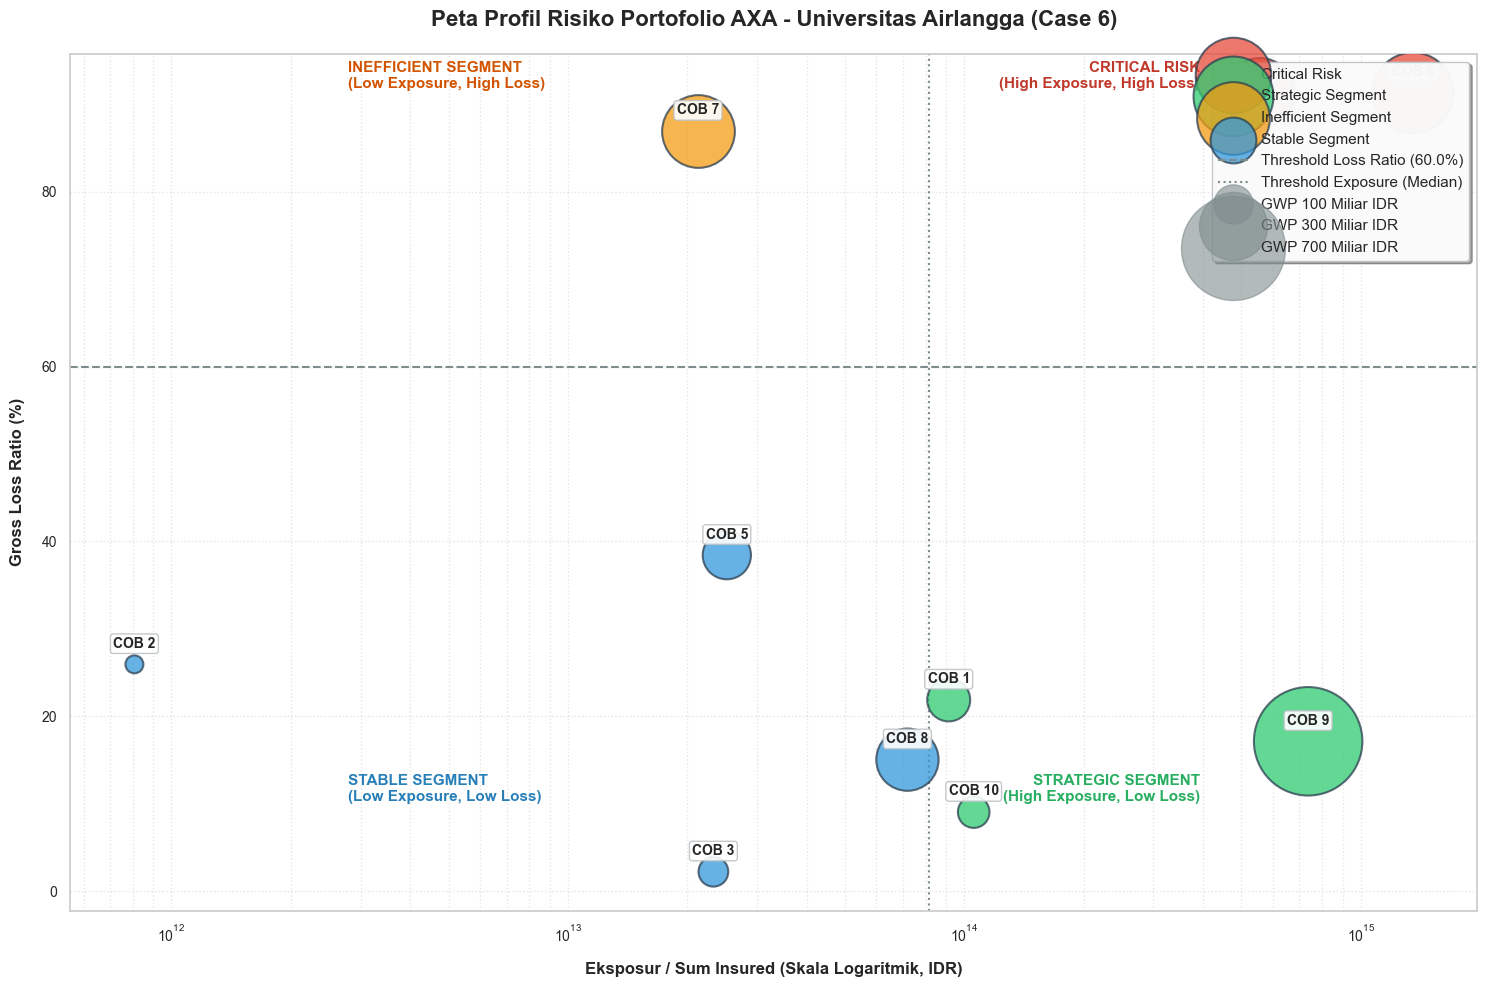

Visualisasi Bubble Chart berhasil dibuat dan disimpan sebagai risk_profile_mapping.png!


In [12]:
# 4. Visualisasi Bubble Chart Peta Profil Risiko
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(15, 10))

# Palet warna premium untuk estetika visual yang wow
color_palette = {
    'Critical Risk': '#e74c3c',       # Merah (Bahaya)
    'Strategic Segment': '#2ecc71',   # Hijau (Unggul/Strategis)
    'Inefficient Segment': '#f39c12', # Oranye (Efisiensi)
    'Stable Segment': '#3498db'       # Biru (Stabil)
}

# Plot titik bubble untuk setiap kategori
for category, color in color_palette.items():
    subset = df_cob[df_cob['Risk_Category'] == category]
    if len(subset) > 0:
        ax.scatter(
            subset['Exposure'],
            subset['Loss_Ratio_Gross'],
            s=subset['GWP'] / 1e9 * 8,  # Ukuran bubble sebanding dengan GWP (skala IDR Miliar)
            c=color,
            label=category,
            alpha=0.75,
            edgecolors='#2c3e50',
            linewidths=1.5,
            zorder=3
        )

# Tambahkan garis batas kuadran
ax.axhline(lr_threshold, color='#7f8c8d', linestyle='--', linewidth=1.5, zorder=2, label=f'Threshold Loss Ratio ({lr_threshold}%)')
ax.axvline(exposure_threshold, color='#7f8c8d', linestyle=':', linewidth=1.5, zorder=2, label=f'Threshold Exposure (Median)')

# Atur sumbu X menjadi skala logaritmik agar penyebaran eksposur (dari Miliar ke Kuadriliun) terlihat seimbang
ax.set_xscale('log')

# Format X-axis ticks to show readable units (IDR T/P)
def format_exposure(x, pos):
    if x >= 1e15:
        return f'IDR {x/1e15:.1f} P' # Kuadriliun (Peta)
    elif x >= 1e12:
        return f'IDR {x/1e12:.0f} T' # Triliun
    elif x >= 1e9:
        return f'IDR {x/1e9:.0f} M' # Miliar
    else:
        return f'IDR {x:,.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_exposure))

# Format label sumbu dan judul yang rapi
ax.set_xlabel('Eksposur / Sum Insured (Skala Logaritmik, IDR)', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('Gross Loss Ratio (%)', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('Peta Profil Risiko Portofolio AXA - Universitas Airlangga (Case 6)', fontsize=16, fontweight='bold', pad=20)

# Dapatkan batas sumbu untuk penempatan teks kuadran
xlim = (df_cob['Exposure'].min() * 0.1, df_cob['Exposure'].max() * 10)
ylim = (0, 110)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Shade quadrants
# Red quadrant: High Exposure, High Loss
ax.fill_between([exposure_threshold, xlim[1]], lr_threshold, ylim[1], color='#e74c3c', alpha=0.04, zorder=1)
# Orange quadrant: Low Exposure, High Loss
ax.fill_between([xlim[0], exposure_threshold], lr_threshold, ylim[1], color='#f39c12', alpha=0.04, zorder=1)
# Green quadrant: High Exposure, Low Loss
ax.fill_between([exposure_threshold, xlim[1]], ylim[0], lr_threshold, color='#2ecc71', alpha=0.04, zorder=1)
# Blue quadrant: Low Exposure, Low Loss
ax.fill_between([xlim[0], exposure_threshold], ylim[0], lr_threshold, color='#3498db', alpha=0.04, zorder=1)

# Menambahkan label nama kuadran di setiap sudut menggunakan transAxes (0-1 range)
ax.text(0.98, 0.97, 'CRITICAL RISK\n(High Exposure, High Loss)', color='#c0392b', fontsize=11, fontweight='bold', ha='right', va='top', transform=ax.transAxes)
ax.text(0.02, 0.97, 'INEFFICIENT SEGMENT\n(Low Exposure, High Loss)', color='#d35400', fontsize=11, fontweight='bold', ha='left', va='top', transform=ax.transAxes)
ax.text(0.98, 0.03, 'STRATEGIC SEGMENT\n(High Exposure, Low Loss)', color='#27ae60', fontsize=11, fontweight='bold', ha='right', va='bottom', transform=ax.transAxes)
ax.text(0.02, 0.03, 'STABLE SEGMENT\n(Low Exposure, Low Loss)', color='#2980b9', fontsize=11, fontweight='bold', ha='left', va='bottom', transform=ax.transAxes)

# Tambahkan label nama COB pada setiap bubble
for i, row in df_cob.iterrows():
    ax.annotate(
        row['COB'],
        (row['Exposure'], row['Loss_Ratio_Gross']),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontweight='bold',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", edgecolor="#bdc3c7", alpha=0.9, zorder=4)
    )

# Pengaturan legend untuk Kategori Risiko dan Ukuran Premi
handles, labels = ax.get_legend_handles_labels()

# Tambahkan representasi ukuran premi ke legend
for gwp_val in [100, 300, 700]:
    ax.scatter([], [], c='#7f8c8d', alpha=0.6, s=gwp_val * 8, label=f'GWP {gwp_val} Miliar IDR')

ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, edgecolor='#bdc3c7', shadow=True)

# Kustomisasi tampilan grid agar bersih
ax.grid(True, which="both", linestyle=':', alpha=0.5, zorder=1)

plt.tight_layout()
plt.savefig('risk_profile_mapping.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualisasi Bubble Chart berhasil dibuat dan disimpan sebagai risk_profile_mapping.png!")


## 6. Kesimpulan Eksekutif & Rekomendasi Strategis

Berdasarkan seluruh temuan analisis **Case 6**, berikut adalah kesimpulan eksekutif dan rekomendasi strategis bisnis yang konkret bagi senior manajemen PT AXA Insurance Indonesia:

### **A. Ringkasan Temuan Utama**
1. **Kesehatan Portofolio**: Secara agregat, portofolio memiliki **Gross Loss Ratio 49.34%** (sangat sehat). Namun, efisiensi reasuransi yang rendah (**Net Loss Ratio 58.54%**) perlu diperbaiki.
2. **Akar Masalah Kerugian**: Kerugian masif berpusat pada **BRANCH K** (regional) dan **CHANNEL B** (jalur distribusi). Produk utama penyebab kerugian adalah **PRODUCT1217** (COB 6) dan **PRODUCT0221** (COB 7) yang terjual di Branch K via Channel B.
3. **Pemetaan Risiko (Risk Quadrant)**:
   - **Critical Risk (COB 6, COB 4, COB 7)**: Segmen dengan pangsa pasar besar (Exposure & GWP tinggi) namun memiliki rasio klaim yang sangat buruk. Ini adalah prioritas utama perbaikan.
   - **Strategic Segment (COB 9)**: Menjadi penyumbang premi terbesar (GWP ~IDR 762 Miliar) dengan tingkat klaim yang sangat rendah (Loss Ratio 17.14%). Segmen ini harus terus didorong ekspansinya.
   - **Stable Segment (COB 1, COB 2, COB 3, COB 5, COB 8, COB 10)**: Memiliki liabilitas kecil dengan profitabilitas underwriting yang baik.

---

### **B. Action Plan Rekomendasi Strategis**

#### **1. Penanganan Segmen Critical Risk (Tindakan Segera)**
- **PRODUCT1217 & PRODUCT0221**: Hentikan penjualan (*suspend*) produk ini untuk nasabah baru di **BRANCH K** melalui **CHANNEL B** selama evaluasi underwriting berjalan. Lakukan audit menyeluruh terhadap pricing dan proses klaim di wilayah tersebut.
- **Underwriting Review**: Tingkatkan tingkat premi (*premium rate load*) atau naikkan batas risiko sendiri (*deductible*) bagi tertanggung di Branch K untuk menekan rasio klaim.
- **Channel B Management**: Channel ini terbukti tidak profitable (Loss Ratio 115.12%). Lakukan re-negosiasi komisi atau pengetatan kriteria seleksi risiko yang masuk melalui perantara di Channel B.

#### **2. Optimasi Program Reasuransi (Insight Aktuaris Tambahan)**
- Terjadi ketidakseimbangan transfer risiko (Cede 21.72% premi, namun hanya pulih 7.20% klaim).
- Perusahaan perlu menaikkan **Retensi Sendiri (*Self-Retention Limit*)** pada lini bisnis yang terbukti sangat menguntungkan seperti **COB 9** (Strategic) agar profit margin bersih tetap tertahan di perusahaan.
- Lakukan negosiasi ulang treaty reasuransi dengan struktur *Non-Proportional* (seperti *Excess of Loss*) untuk melindungi portofolio dari klaim besar di COB 6 dan COB 7, daripada menggunakan skema *Quota Share* yang membagi premi profitable ke reasuradur.

#### **3. Ekspansi Segmen Unggul**
- Alokasikan anggaran pemasaran dan komisi insentif tambahan untuk memacu pertumbuhan **COB 9** di seluruh cabang, karena segmen ini adalah jangkar profit terbesar bagi perusahaan saat ini.
